# Notebook 1 — Exploratory Data Analysis & Distribution Fitting
### Project: *Rare-Event Estimation in Water-Quality Control*

**Goal of this notebook.** Before we can simulate anything, we need to understand the
real data and build a probabilistic model for it. Concretely we will:

1. Load the `water_potability.csv` dataset and inspect it.
2. Pick a continuous target variable (**Chloramines**) and study its empirical distribution.
3. Fit several candidate distributions by **Maximum-Likelihood Estimation (MLE)** —
   Normal, Gamma and Weibull — and compare them with log-likelihood, **AIC/BIC** and the
   **Kolmogorov–Smirnov** statistic.
4. Choose the best model \(f(x)\) and define a **rare-event threshold** \(\tau\) such that
   \(P(X>\tau)\approx 10^{-4}\).
5. Save the fitted parameters to `results/fitted_params.json` so the other three notebooks
   can reuse exactly the same model.

> The deviation of a water parameter beyond its safety limit is a *rare event*: treatment
> systems are usually stable, so such excursions are seldom observed in finite sampling.
> Estimating their probability reliably is precisely what notebooks 3 (Monte-Carlo) and
> 4 (Importance Sampling) are about.

In [1]:
import json
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

SEED = 42
rng = np.random.default_rng(SEED)


def find_project_root() -> Path:
    """Locate the project root so notebooks run from any working directory."""
    here = Path.cwd().resolve()
    for cand in [here, *here.parents]:
        if (cand / "data" / "water_potability.csv").exists():
            return cand
    # fall back to the parent of a "notebooks" folder if present
    if here.name == "notebooks":
        return here.parent
    return here


ROOT = find_project_root()
DATA_PATH = ROOT / "data" / "water_potability.csv"
RESULTS = ROOT / "results"
RESULTS.mkdir(parents=True, exist_ok=True)
print("Project root :", ROOT)
print("Data file    :", DATA_PATH, "(exists:", DATA_PATH.exists(), ")")
print("Results dir  :", RESULTS)

Project root : /home/claude/Water_Quality_Rare_Events
Data file    : /home/claude/Water_Quality_Rare_Events/data/water_potability.csv (exists: True )
Results dir  : /home/claude/Water_Quality_Rare_Events/results


## 1. Load the dataset and first inspection

In [2]:
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()

Shape: (3276, 10)


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [3]:
# Numerical summary of every column
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ph,2785.0,7.080795,1.594320,0.000000,6.093092,7.036752,8.062066,14.000000
Hardness,3276.0,196.369496,32.879761,47.432000,176.850538,196.967627,216.667456,323.124000
Solids,3276.0,22014.092526,8768.570828,320.942611,15666.690297,20927.833607,27332.762127,61227.196008
Chloramines,3276.0,7.122277,1.583085,0.352000,6.127421,7.130299,8.114887,13.127000
Sulfate,2495.0,333.775777,41.416840,129.000000,307.699498,333.073546,359.950170,481.030642
Conductivity,3276.0,426.205111,80.824064,181.483754,365.734414,421.884968,481.792304,753.342620
Organic_carbon,3276.0,14.284970,3.308162,2.200000,12.065801,14.218338,16.557652,28.300000
Trihalomethanes,3114.0,66.396293,16.175008,0.738000,55.844536,66.622485,77.337473,124.000000
Turbidity,3276.0,3.966786,0.780382,1.450000,3.439711,3.955028,4.500320,6.739000
Potability,3276.0,0.390110,0.487849,0.000000,0.000000,0.000000,1.000000,1.000000


In [4]:
# Missing-value report
missing = df.isna().sum().to_frame("n_missing")
missing["pct"] = (100 * missing["n_missing"] / len(df)).round(2)
missing

,n_missing,pct
ph,491,14.99
Hardness,0,0.00
Solids,0,0.00
Chloramines,0,0.00
Sulfate,781,23.84
Conductivity,0,0.00
Organic_carbon,0,0.00
Trihalomethanes,162,4.95
Turbidity,0,0.00
Potability,0,0.00


## 2. Target variable and missing values

The project asks us to model **pH** or **Chloramines**. We choose **Chloramines** because:

* it is a continuous concentration with a clear public-health threshold (excess chloramine
  is itself a contaminant), giving a natural upper-tail rare event \(P(X>\tau)\);
* it has **no missing values** in this dataset, so the model is not biased by imputation.

`ph`, `Sulfate` and `Trihalomethanes` contain missing entries; since we do not use them as
the simulation target we simply leave them untouched (we only peek at `ph` for context).

In [5]:
TARGET = "Chloramines"
x = df[TARGET].dropna().to_numpy()
print(f"{TARGET}: n = {len(x)}  (no missing values)")

desc = {
    "n": len(x),
    "mean": x.mean(),
    "std": x.std(ddof=1),
    "min": x.min(),
    "max": x.max(),
    "skewness": stats.skew(x),
    "excess_kurtosis": stats.kurtosis(x),
}
pd.Series(desc).round(4)

Chloramines: n = 3276  (no missing values)


n                  3276.0000
mean                  7.1223
std                   1.5831
min                   0.3520
max                  13.1270
skewness             -0.0121
excess_kurtosis       0.5872
dtype: float64

## 3. Exploratory data analysis

The skewness is essentially zero, so the variable looks close to symmetric. We visualise the
histogram, a kernel-density estimate and a box-plot. For context we also show `ph`.

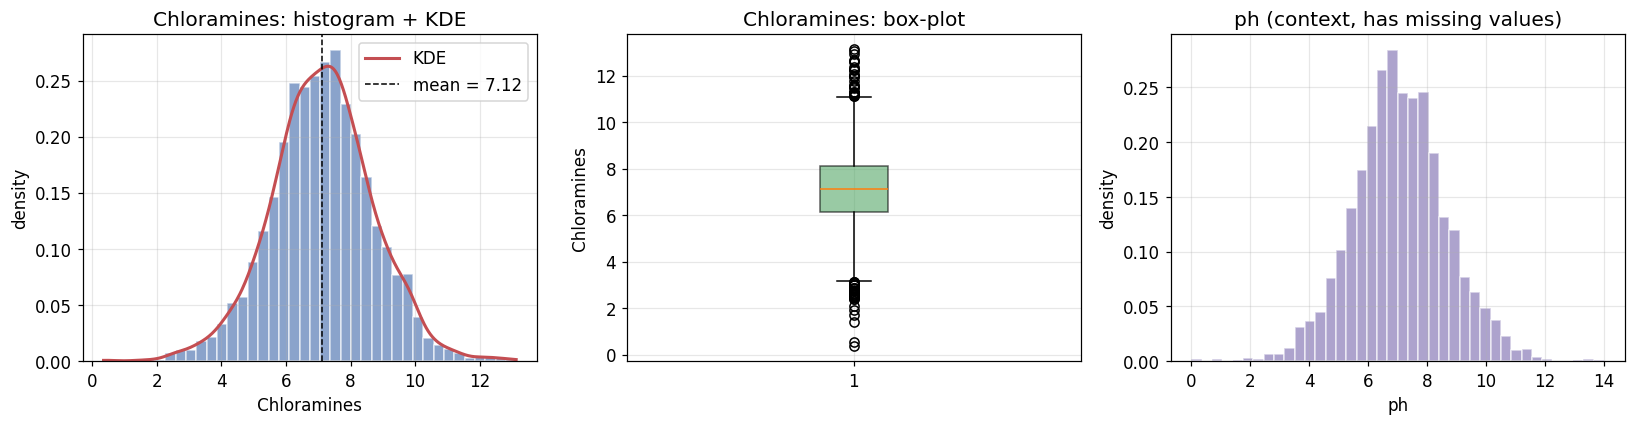

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# histogram + KDE for Chloramines
axes[0].hist(x, bins=40, density=True, color="#4C72B0", alpha=0.65, edgecolor="white")
kde = stats.gaussian_kde(x)
grid = np.linspace(x.min(), x.max(), 400)
axes[0].plot(grid, kde(grid), color="#C44E52", lw=2, label="KDE")
axes[0].axvline(x.mean(), color="k", ls="--", lw=1, label=f"mean = {x.mean():.2f}")
axes[0].set_title(f"{TARGET}: histogram + KDE")
axes[0].set_xlabel(TARGET); axes[0].set_ylabel("density"); axes[0].legend()

# box-plot
axes[1].boxplot(x, vert=True, patch_artist=True,
                boxprops=dict(facecolor="#55A868", alpha=0.6))
axes[1].set_title(f"{TARGET}: box-plot"); axes[1].set_ylabel(TARGET)

# ph for context
ph = df["ph"].dropna().to_numpy()
axes[2].hist(ph, bins=40, density=True, color="#8172B3", alpha=0.65, edgecolor="white")
axes[2].set_title("ph (context, has missing values)")
axes[2].set_xlabel("ph"); axes[2].set_ylabel("density")

plt.tight_layout()
plt.savefig(RESULTS / "01_eda_overview.png", bbox_inches="tight")
plt.show()

## 4. Distribution fitting by Maximum-Likelihood Estimation

We fit three candidate families to \(X=\) Chloramines:

* **Normal** \(\mathcal N(\mu,\sigma)\),
* **Gamma** \(\Gamma(k,\theta)\) (location fixed at 0),
* **Weibull** (minimum, location fixed at 0).

`scipy.stats.<dist>.fit` performs **MLE**: it maximises the log-likelihood
\(\ell(\theta)=\sum_i \log f(x_i;\theta)\). We compare the fits with three criteria:

* **log-likelihood** (higher is better),
* **AIC** \(=2k-2\ell\) and **BIC** \(=k\ln n-2\ell\) (lower is better — they penalise extra
  parameters),
* the **Kolmogorov–Smirnov** statistic (lower = closer empirical/theoretical CDF).

In [7]:
n = len(x)

def loglik(dist, params):
    return np.sum(dist.logpdf(x, *params))

fits = {}

# Normal (2 params)
p_norm = stats.norm.fit(x)
fits["Normal"] = dict(dist="norm", params=p_norm, k=2)

# Gamma with loc fixed at 0 (2 free params: shape, scale)
p_gam = stats.gamma.fit(x, floc=0)
fits["Gamma"] = dict(dist="gamma", params=p_gam, k=2)

# Weibull (minimum) with loc fixed at 0 (2 free params: c, scale)
p_wei = stats.weibull_min.fit(x, floc=0)
fits["Weibull"] = dict(dist="weibull_min", params=p_wei, k=2)

rows = []
for name, info in fits.items():
    dist = getattr(stats, info["dist"])
    ll = loglik(dist, info["params"])
    aic = 2 * info["k"] - 2 * ll
    bic = info["k"] * np.log(n) - 2 * ll
    ks = stats.kstest(x, info["dist"], args=info["params"]).statistic
    info["loglik"], info["AIC"], info["BIC"], info["KS"] = ll, aic, bic, ks
    rows.append([name, ll, aic, bic, ks])

fit_table = (pd.DataFrame(rows, columns=["model", "loglik", "AIC", "BIC", "KS"])
               .set_index("model")
               .sort_values("AIC"))
fit_table.round(3)

,loglik,AIC,BIC,KS
model,,,,
Normal,-6152.856,12309.713,12321.902,0.021
Weibull,-6206.582,12417.165,12429.354,0.039
Gamma,-6281.558,12567.116,12579.305,0.047


In [8]:
# Print the actual fitted parameters of each model
for name, info in fits.items():
    print(f"{name:8s}: params = {tuple(round(float(v),4) for v in info['params'])}")

Normal  : params = (7.1223, 1.5828)
Gamma   : params = (18.0283, 0.0, 0.3951)
Weibull : params = (4.8842, 0.0, 7.7437)


### 4b. Sanity check — manual MLE for the Normal model

For the Normal distribution the MLE has a closed form,
\(\hat\mu=\frac1n\sum x_i\) and \(\hat\sigma=\sqrt{\frac1n\sum (x_i-\hat\mu)^2}\).
We verify that our manual computation reproduces `scipy`'s result, and we also confirm the
Gamma fit by directly minimising the negative log-likelihood with a numerical optimiser.

In [9]:
from scipy.optimize import minimize

# Manual normal MLE (note: population std, ddof=0)
mu_hat = x.mean()
sig_hat = np.sqrt(np.mean((x - mu_hat) ** 2))
print(f"Manual normal MLE : mu={mu_hat:.5f}, sigma={sig_hat:.5f}")
print(f"scipy  normal MLE : mu={p_norm[0]:.5f}, sigma={p_norm[1]:.5f}")

# Manual gamma MLE by numerical optimisation (loc fixed at 0)
def neg_loglik_gamma(p):
    k, scale = p
    if k <= 0 or scale <= 0:
        return np.inf
    return -np.sum(stats.gamma.logpdf(x, k, 0, scale))

res = minimize(neg_loglik_gamma, x0=[10.0, 0.5], method="Nelder-Mead")
print(f"\nManual gamma MLE  : k={res.x[0]:.4f}, scale={res.x[1]:.4f}")
print(f"scipy  gamma MLE  : k={p_gam[0]:.4f}, scale={p_gam[2]:.4f}")

Manual normal MLE : mu=7.12228, sigma=1.58284
scipy  normal MLE : mu=7.12228, sigma=1.58284

Manual gamma MLE  : k=18.0283, scale=0.3951
scipy  gamma MLE  : k=18.0283, scale=0.3951


## 5. Visual goodness-of-fit: overlaid densities and Q–Q plot

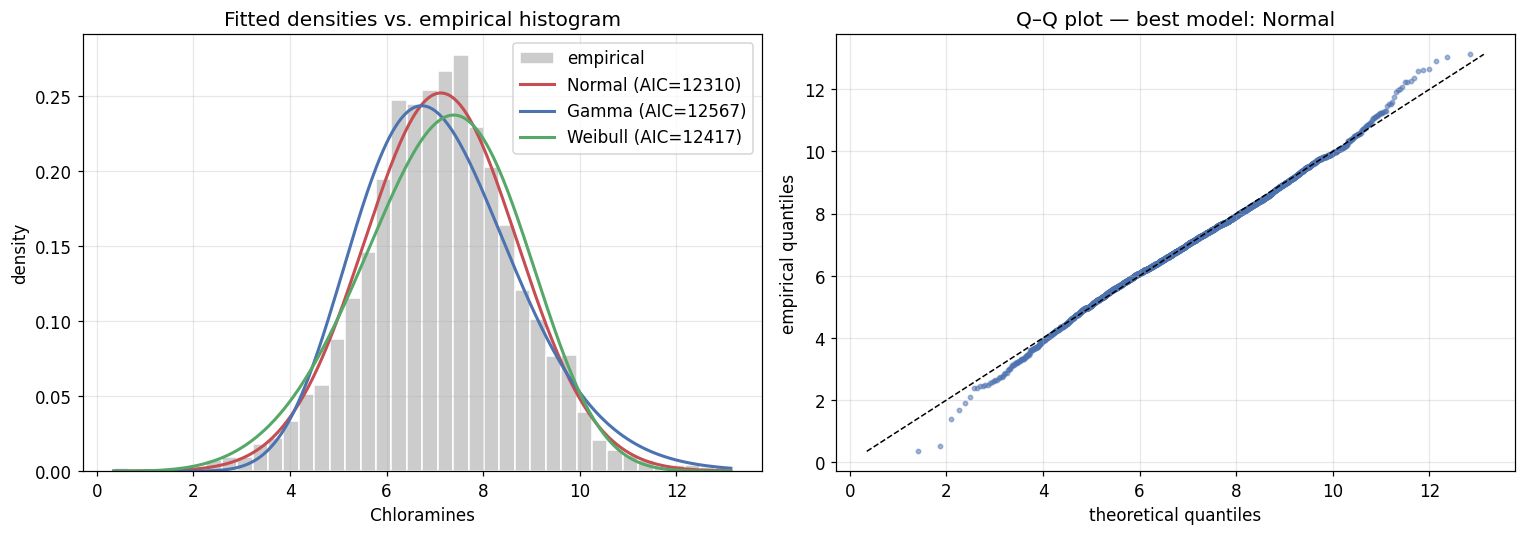

Best model by AIC: Normal


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) histogram with the three fitted PDFs
axes[0].hist(x, bins=40, density=True, color="0.8", edgecolor="white", label="empirical")
grid = np.linspace(x.min(), x.max(), 400)
colors = {"Normal": "#C44E52", "Gamma": "#4C72B0", "Weibull": "#55A868"}
for name, info in fits.items():
    dist = getattr(stats, info["dist"])
    axes[0].plot(grid, dist.pdf(grid, *info["params"]),
                 lw=2, color=colors[name],
                 label=f"{name} (AIC={info['AIC']:.0f})")
axes[0].set_title("Fitted densities vs. empirical histogram")
axes[0].set_xlabel(TARGET); axes[0].set_ylabel("density"); axes[0].legend()

# (b) Q-Q plot for the best model (lowest AIC)
best_name = fit_table.index[0]
best = fits[best_name]
best_dist = getattr(stats, best["dist"])
probs = (np.arange(1, n + 1) - 0.5) / n
theo_q = best_dist.ppf(probs, *best["params"])
emp_q = np.sort(x)
axes[1].scatter(theo_q, emp_q, s=8, alpha=0.5, color="#4C72B0")
lims = [min(theo_q.min(), emp_q.min()), max(theo_q.max(), emp_q.max())]
axes[1].plot(lims, lims, "k--", lw=1)
axes[1].set_title(f"Q–Q plot — best model: {best_name}")
axes[1].set_xlabel("theoretical quantiles"); axes[1].set_ylabel("empirical quantiles")

plt.tight_layout()
plt.savefig(RESULTS / "01_fit_comparison.png", bbox_inches="tight")
plt.show()

print(f"Best model by AIC: {best_name}")

**Interpretation.** Chloramines is almost perfectly symmetric (skewness \(\approx 0\)),
so the **Normal** model attains the lowest AIC/BIC and the smallest KS statistic — it is the
best description of *this* variable. Gamma and Weibull are designed for skewed positive data
and here they fit slightly worse; they would be the natural choice for strongly right-skewed
water variables such as `Solids`. We therefore adopt the **Normal** model as our working
distribution \(f(x)\) for the rare-event study, which also yields the cleanest Importance-
Sampling setup in notebook 4.

## 6. Rare-event threshold and saving the model

We define the threshold \(\tau\) so that, under the fitted model, the exceedance probability is
\(\gamma = P(X>\tau)\approx 10^{-4}\). This is the small probability the later notebooks must
estimate. We save everything needed downstream to `results/fitted_params.json`.

In [11]:
best_name = fit_table.index[0]
best = fits[best_name]
best_dist = getattr(stats, best["dist"])

TARGET_PROB = 1e-4
tau = float(best_dist.ppf(1 - TARGET_PROB, *best["params"]))
gamma_true = float(best_dist.sf(tau, *best["params"]))

print(f"Working model     : {best_name}  params={tuple(round(float(v),4) for v in best['params'])}")
print(f"Rare-event thresh : tau = {tau:.4f}")
print(f"True probability  : gamma = P(X>tau) = {gamma_true:.3e}")
print(f"Max observed value: {x.max():.4f}  -> tau sits at the edge of / beyond the data (genuinely rare)")

params_out = {
    "target": TARGET,
    "best_model": best_name,
    "scipy_dist": best["dist"],
    "params": [float(v) for v in best["params"]],
    "mu": float(x.mean()),
    "sigma": float(x.std(ddof=1)),
    "tau": tau,
    "gamma_true": gamma_true,
    "target_prob": TARGET_PROB,
    "data_min": float(x.min()),
    "data_max": float(x.max()),
    "all_fits": {name: {"params": [float(v) for v in info["params"]],
                         "AIC": float(info["AIC"]), "KS": float(info["KS"])}
                 for name, info in fits.items()},
}
with open(RESULTS / "fitted_params.json", "w") as fh:
    json.dump(params_out, fh, indent=2)
print("\nSaved -> results/fitted_params.json")

Working model     : Normal  params=(7.1223, 1.5828)
Rare-event thresh : tau = 13.0089
True probability  : gamma = P(X>tau) = 1.000e-04
Max observed value: 13.1270  -> tau sits at the edge of / beyond the data (genuinely rare)

Saved -> results/fitted_params.json


### Summary

* Target variable: **Chloramines** (continuous, complete).
* Best model by AIC/BIC/KS: **Normal** \(\mathcal N(\mu,\sigma)\).
* Rare-event threshold \(\tau\) chosen so that \(\gamma=P(X>\tau)\approx10^{-4}\).
* Model + threshold written to `results/fitted_params.json`.

➡️ **Next:** Notebook 2 implements the **Accept–Reject** algorithm from scratch to draw
samples from this fitted \(f(x)\), and checks that the generated data reproduces the real
histogram.